# script to plot ancestry PCA

PCA loadings are from Somalier

## 00 prepare input VCF file and somalier input files
- use variants lifted over to hg38
```
ml BCFtools/1.22-GCC-10.3.0
bcftools annotate -W -x 'FORMAT/AD' /ASA/analysis/20241004_patient_demultiplexing/WGS_chm13_BCFs_merged/WGS_chm13_BCFs.missing_to_ref.norm.remove_overlaps.snps.chm13_to_hg38.vcf.gz -o WGS_chm13_BCFs.missing_to_ref.norm.remove_overlaps.snp
s.chm13_to_hg38.no_AD.vcf.gz

# get sites
wget https://github.com/brentp/somalier/files/3412456/sites.hg38.vcf.gz
# get ancestry labels
wget https://raw.githubusercontent.com/brentp/somalier/master/scripts/ancestry-labels-1kg.tsv
# get somalier files for 1KGP
wget https://zenodo.org/record/3479773/files/1kg.somalier.tar.gz?download=1
mv 1kg.somalier.tar.gz?download=1 1kg.somalier.tar.gz
gzip -d 1kg.somalier.tar.gz
tar -xvf 1kg.somalier.tar
```

## 01 extract somalier site
```
more 01_hg38_somalier_extract.sh
#!/bin/bash
SITES="sites.hg38.vcf.gz"
COHORT="WGS_chm13_BCFs.missing_to_ref.norm.remove_overlaps.snps.chm13_to_hg38.no_AD.vcf.gz"
GENOME="/references/GRCh38.alt-masked-V2/fasta/Homo_sapiens_assembly38_masked.fasta"
OUT_DIR="/somalier"

apptainer run -B /staging/leuven/ \
/apancik/software/singularity/somalier_v0.2.19.sif \
somalier extract -d $OUT_DIR/hg38_somalier_extracted/ --sites $SITES -f $GENOME $COHORT
```
## 02 run ancestry prediction
```
#!/bin/bash
WORK_DIR="/somalier"

current_date=$(date +%Y%m%d)

apptainer run -B /staging/leuven/\
/software/singularity/somalier_v0.2.19.sif \
somalier ancestry --labels ${WORK_DIR}/ancestry-labels-1kg.tsv -o ${WORK_DIR}/hg38_ancestry_${current_date} \
${WORK_DIR}/1kg-somalier/*.somalier ++ ${WORK_DIR}/hg38_somalier_extracted/*.somalier
```

In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# to save the figures in adobe friendly fashion
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

In [ ]:
# load file
ancestry = pd.read_csv('/WGS_pop_variants/somalier/hg38_ancestry_20251028.somalier-ancestry.tsv', sep = '\t') # change path as necessary

In [4]:
subset  = ancestry[ancestry['given_ancestry'].isna()]
subset.predicted_ancestry.value_counts()

EUR    185
AMR      2
EAS      1
Name: predicted_ancestry, dtype: int64

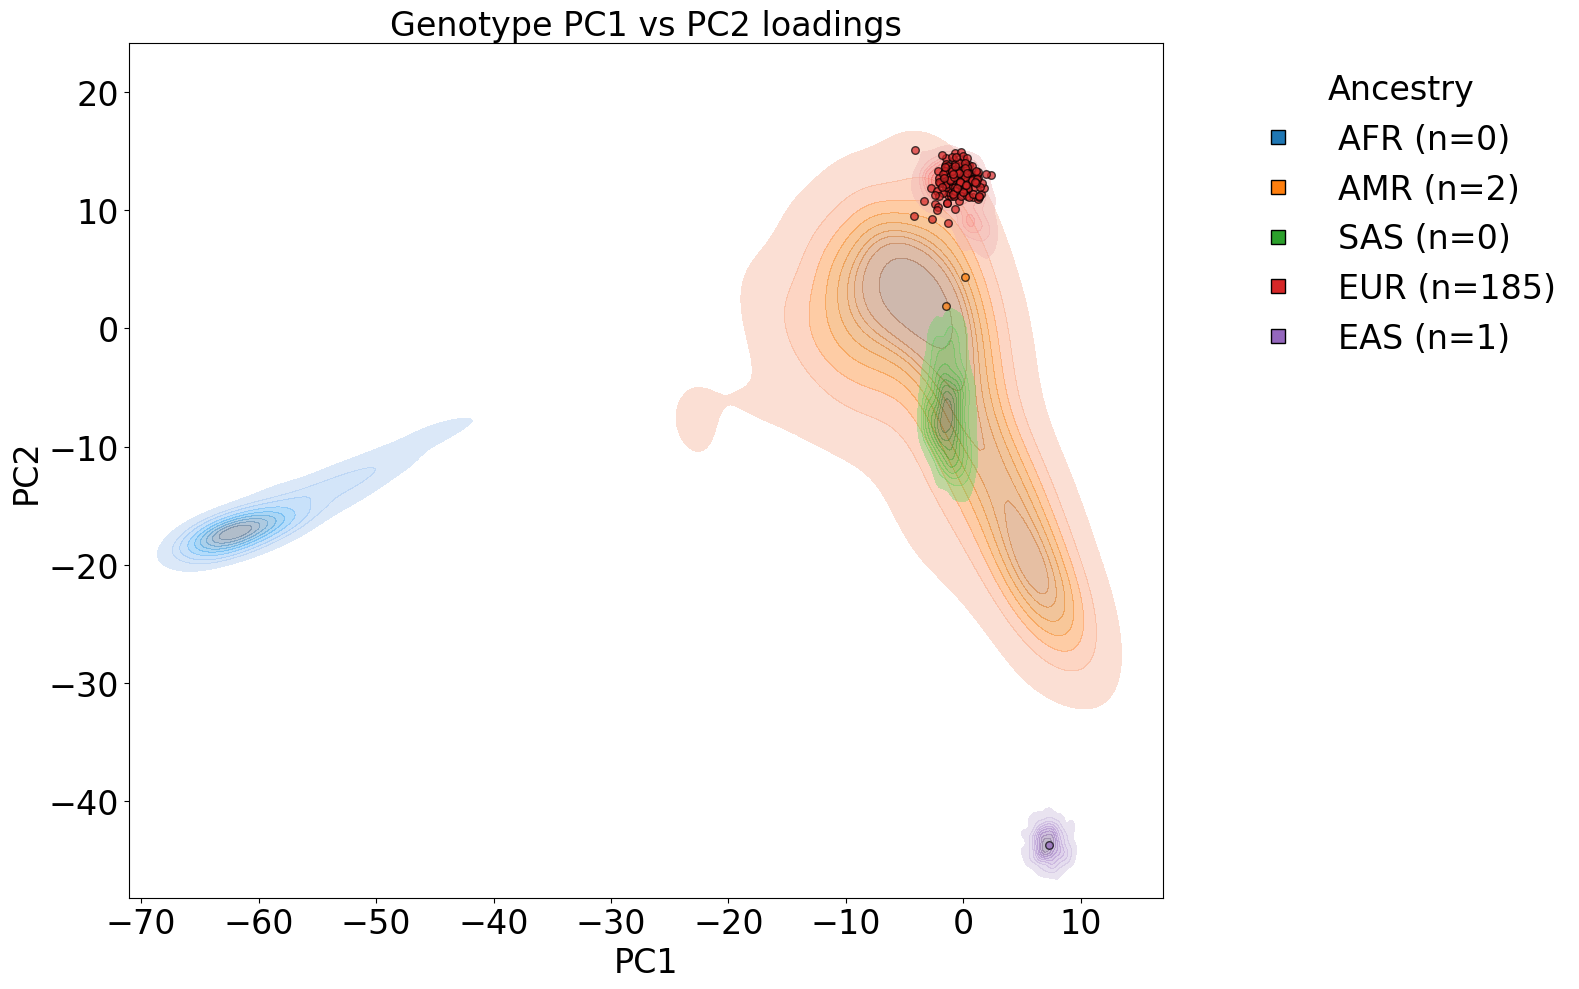

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

font_size = 24

plt.figure(figsize=(16, 10))

# Palette for given ancestry
given_palette = dict(
    zip(
        ancestry['given_ancestry'].dropna().unique(),
        sns.color_palette("tab10", ancestry['given_ancestry'].dropna().nunique())
    )
)

# Plot KDE for each given ancestry group
for anc, color in given_palette.items():
    subset = ancestry[ancestry['given_ancestry'] == anc]
    if not subset.empty:
        sns.kdeplot(
            x=subset['PC1'],
            y=subset['PC2'],
            fill=True,
            alpha=0.4,
            color=color,
        )


missing = ancestry[ancestry['given_ancestry'].isna()]
palette_pred = dict(
    zip(
        ancestry['predicted_ancestry'].unique(),
        sns.color_palette("tab10", ancestry['predicted_ancestry'].nunique())
    )
)

for idx, row in missing.iterrows():
    fc = palette_pred[row['predicted_ancestry']]
    plt.scatter(
        row['PC1'], row['PC2'],
        c=[fc],
        edgecolors='black',
        marker='o',
        s=30,
        alpha=0.7,
        rasterized=True
    )

plt.xlabel('PC1', fontsize=font_size)
plt.ylabel('PC2', fontsize=font_size)
plt.title('Genotype PC1 vs PC2 loadings', fontsize=font_size)
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)

handles = [
    plt.Line2D(
        [0], [0],
        marker='s',
        color='w',
        label=f"{anc} (n={((ancestry['predicted_ancestry'] == anc) & ancestry['given_ancestry'].isna()).sum()})",
        markerfacecolor=palette_pred[anc],
        markeredgecolor='black',
        markersize=10
    )
    for anc in ancestry['predicted_ancestry'].unique()
]

plt.legend(
    handles=handles,
    title='Ancestry',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    frameon=False,
    fontsize=font_size,
    title_fontsize=font_size
)

plt.tight_layout()
plt.savefig('figures/ancestry.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [10]:
pip list

Package                              Version
------------------------------------ -----------------
adjustText                           1.0.4
aiohttp                              3.9.3
aiosignal                            1.3.1
anndata                              0.10.5.post1
annoy                                1.17.3
appdirs                              1.4.4
arboreto                             0.1.6
argparse-dataclass                   2.0.0
array_api_compat                     1.5.1
asttokens                            2.4.1
attr                                 0.3.2
attrs                                23.2.0
bbknn                                1.6.0
beautifulsoup4                       4.12.3
bidict                               0.23.1
bioservices                          1.11.2
blosc2                               2.5.1
bokeh                                3.4.0
boltons                              23.1.1
bs4                                  0.0.2
cattrs                     